## The question I want to answer is:

### **What are the implications of higher blood pressure?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# Load the datasets
blood_pressure_df = pd.read_csv("../data/week4/blood_pressure.csv")
heart_rate_df = pd.read_csv("../data/week4/heart_rate.csv")
sleep_df = pd.read_csv("../data/week4/sleep.csv")
participants_df = pd.read_csv("../data/week4/participants.csv")

display(blood_pressure_df.head())
display(heart_rate_df.head())
display(sleep_df.head())
display(participants_df.head())


,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.4
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.0


,user_code,datetime,heart_rate,is_resting
0,007b8190cf,2020-04-26 04:49:25,70,0
1,01bad5a519,2020-04-23 06:21:03,74,0
2,01bad5a519,2020-04-23 09:46:01,82,0
3,01bad5a519,2020-04-23 14:05:06,90,0
4,01bad5a519,2020-04-24 03:41:18,72,0


,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


## Data Context & Sampling


All of the csv files used are from the 2020 Welltory COVID-19 dataset. The data collected was heart rate variability (HRV) metrics, data from user worn wearables, and professional health assessments. All of the users in this dataset are patients who tested positive for COVID-19. The question I wanted to explore was *"What are the implications of higher blood pressure?"*, and so the relevant datasets were: 

- **`blood_pressure.csv`** (721 rows, 28 users) — the primary outcome of interest: systolic/diastolic readings plus a few derived cardiovascular indices.
- **`participants.csv`** (185 rows, 1 row/person) — demographic and physical context (age range, gender, height, weight, country) to see who has higher blood pressure and why.
- **`heart_rate.csv`** (523,783 rows, 79 users) — a related physiological signal, used here as a per-user average to see how heart rate and blood pressure relate.
- **`sleep.csv`** (425 rows, 10 users) — used for a small, exploratory look at whether sleep duration relates to blood pressure.

It is important to note that there was *no random sampling* in this study. All of the users were positive-testing COVID-19 patients who *volunatirly* submitted these metrics. 


In [2]:
# Data structure: shapes, dtypes, and how the tables relate to each other
for name, df in [
    ("blood_pressure_df", blood_pressure_df),
    ("heart_rate_df", heart_rate_df),
    ("sleep_df", sleep_df),
    ("participants_df", participants_df),
]:
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} cols")
print()
blood_pressure_df.info()
print()
participants_df.info()

bp_users = set(blood_pressure_df["user_code"])
print(f"\nUsers with a blood pressure record: {len(bp_users)} of {participants_df['user_code'].nunique()} total participants")
print(f"Of those, present in heart_rate.csv: {len(bp_users & set(heart_rate_df['user_code']))}")
print(f"Of those, present in sleep.csv:      {len(bp_users & set(sleep_df['user_code']))}")


blood_pressure_df: 721 rows x 8 cols
heart_rate_df: 523783 rows x 4 cols
sleep_df: 425 rows x 12 cols
participants_df: 185 rows x 8 cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_code                 721 non-null    object 
 1   measurement_datetime      721 non-null    object 
 2   diastolic                 721 non-null    int64  
 3   systolic                  721 non-null    int64  
 4   functional_changes_index  299 non-null    float64
 5   circulatory_efficiency    299 non-null    float64
 6   kerdo_vegetation_index    283 non-null    float64
 7   robinson_index            299 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 45.2+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dty

### Interpreting the data structure

Looking at the shapes of the dataframes, it is clear that there is an imbalance in the quantity of data for each category. Specifically, there are only 185 unique participants but over 500k heart rate readings and around 700 blood pressure readings. This makes sense, since the frequency at which the different metrics are recorded is completely different. 

Another point is that not every participant has blood pressure data. Only 28 of the 185 people have an entry in the blood pressure csv file, which means that for the research question *What are the implications of high blood pressure?*, we only have 28 unique participants out of 185 total participants with enough data. 

A third point is that datetime columns are stored as strings, so date arithmetic won't apply to these columns automatically and will need conversion later. 


In [3]:
# Descriptive statistics
print("Blood pressure numeric summary:")
display(blood_pressure_df.describe())

print("\nParticipants numeric summary:")
display(participants_df.describe())

print("\nParticipants categorical summary:")
display(participants_df[["gender", "age_range", "country"]].describe())

print("\nAge range distribution:")
print(participants_df["age_range"].value_counts())
print("\nGender distribution:")
print(participants_df["gender"].value_counts())


Blood pressure numeric summary:


,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
count,721.000000,721.000000,299.000000,299.000000,283.000000,299.000000
mean,81.228849,119.441054,2.594013,2735.197057,-15.498233,84.663779
std,8.865761,10.522578,0.291302,747.882570,18.681233,14.399208
min,25.000000,63.000000,1.680000,1300.000000,-76.000000,49.500000
25%,76.000000,113.000000,2.440000,2250.500000,-29.000000,75.580000
50%,82.000000,120.000000,2.580000,2640.000000,-17.000000,83.220000
75%,88.000000,126.000000,2.730000,3076.500000,-5.000000,93.170000
max,101.000000,157.000000,3.510000,7875.000000,45.000000,164.850000



Participants numeric summary:


,height,weight
count,183.000000,185.000000
mean,169.976393,77.927757
std,12.400103,19.552541
min,132.080000,43.500000
25%,163.500000,63.500000
50%,168.000000,74.344000
75%,174.500000,90.537000
max,250.000000,154.221000



Participants categorical summary:


,gender,age_range,country
count,185,185,179
unique,2,6,25
top,f,35-44,Russia
freq,118,56,66



Age range distribution:
age_range
35-44    56
45-54    51
25-34    46
18-24    16
55-64     9
65-74     7
Name: count, dtype: int64

Gender distribution:
gender
f    118
m     67
Name: count, dtype: int64


### Interpreting the descriptive statistics

**Some prerequisite context:**

**Systolic pressure:** Measures the force of someone's blood against artery walls
- Normal Range: <120 mm Hg
- Elevated: 120 to 129 mm Hg
- High Blood Pressure (Stage 1): 130 to 139 mm Hg
- High Blood Pressure (Stage 2): 140 mm Hg or higher
- Extremely High Blood Pressure: 180 mm Hg or higher

**Diastolic pressure:** Measures the pressure in someone's arteries when their heart rests between beats
- Normal range: 60 to 80 mm Hg
- Stage 1 Hypertension: 80 to 89 mm Hg
- Stage 2 Hypertension: >90 mm Hg

The mean systolic pressure (120 mmHg) and diastolic pressure (81 mmHg) are both in the healthy range, but the standard deviations are very high (10.5 mmHg and 8.9 mmHg respectively). The min/max ranges also show substantial spread, with the range for systolic and diastolic being 63-157 and 25-101 respectively. The `age_range` distribution is also pretty imbalanced, since there are only 16 people in each of the 18-24 and 55-74 categories, meaning that conclusions about people in these age groups should be considered carefully. 


In [4]:
# Investigate missing values: counts and percentages per column
for name, df in [("blood_pressure_df", blood_pressure_df), ("participants_df", participants_df), ("sleep_df", sleep_df)]:
    print(f"--- {name} ---")
    missing = pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(1),
    })
    display(missing[missing["n_missing"] > 0])
    print()


--- blood_pressure_df ---


,n_missing,pct_missing
functional_changes_index,422,58.5
circulatory_efficiency,422,58.5
kerdo_vegetation_index,438,60.7
robinson_index,422,58.5



--- participants_df ---


,n_missing,pct_missing
city,12,6.5
country,6,3.2
height,2,1.1
symptoms_onset,38,20.5



--- sleep_df ---


,n_missing,pct_missing
sleep_awake_duration,416,97.9
sleep_rem_duration,418,98.4
sleep_light_duration,398,93.6
sleep_deep_duration,411,96.7
pulse_min,410,96.5
pulse_max,410,96.5
pulse_average,410,96.5


### Missing values: discussion and strategy

Some columns have more missing data than others, so the strategy changes depending on how much is missing:
- small amount (< 20% missing)
- medium amount (20-50% missing)
- large amount (>50% missing)

**Small amount:**
- `symptoms_onset`: probably means the person hadn't reported symptoms yet. I leave it missing since there's no reasonable way to guess a date.
- `city`/`country`: left as-is, not used in the numeric analysis.
- `height`: only 2 missing, so I leave these `NaN` and let `bmi` be `NaN` for those rows instead of guessing a height.

**Large amount:**
- `functional_changes_index`, `circulatory_efficiency`, `kerdo_vegetation_index`, `robinson_index` are 58-61% missing. I almost dropped these since I wasn't planning to use them, but it turns out they're the columns most correlated with blood pressure in the whole dataset (see below), so they're too relevant to drop. The app only computes them when a heart rate reading exists at the same time, so the missingness isn't random, and imputing would mean guessing a number the sensor never produced. Instead I use a complete-case subset (drop rows missing these columns) whenever I actually analyze them, and keep the full data everywhere else.

In short, I don't impute anything. Missing values are either left alone (not used downstream) or handled with a complete-case subset when the column actually matters.


In [5]:
# Implement missing-value handling for the derived cardiovascular indices: complete-case
# (listwise) subset, since these are formula-derived values that cannot be legitimately
# imputed, but are too clinically relevant to the research question to just drop.
derived_index_cols = ["functional_changes_index", "circulatory_efficiency", "kerdo_vegetation_index", "robinson_index"]
bp_with_indices = blood_pressure_df.dropna(subset=derived_index_cols).copy()
print(f"blood_pressure: {len(blood_pressure_df)} -> {len(bp_with_indices)} rows with all 4 derived indices present")

print("\nCorrelation of derived cardiovascular indices with systolic/diastolic pressure:")
display(bp_with_indices[derived_index_cols + ["systolic", "diastolic"]].corr()[["systolic", "diastolic"]].round(2))


blood_pressure: 721 -> 283 rows with all 4 derived indices present

Correlation of derived cardiovascular indices with systolic/diastolic pressure:


,systolic,diastolic
functional_changes_index,0.68,0.63
circulatory_efficiency,0.57,-0.22
kerdo_vegetation_index,-0.38,-0.51
robinson_index,0.47,0.38
systolic,1.00,0.50
diastolic,0.50,1.00


In [6]:
# Check for duplicate records: exact-row duplicates and duplicate natural keys
print("Exact duplicate rows:")
print("  blood_pressure.csv:", blood_pressure_df.duplicated().sum())
print("  participants.csv:  ", participants_df.duplicated().sum())
print("  sleep.csv:          ", sleep_df.duplicated().sum())

print("\nDuplicate natural keys:")
print("  blood_pressure (user_code + measurement_datetime):",
      blood_pressure_df.duplicated(subset=["user_code", "measurement_datetime"]).sum())
print("  participants (user_code):", participants_df.duplicated(subset=["user_code"]).sum())
print("  sleep (user_code + day):", sleep_df.duplicated(subset=["user_code", "day"]).sum())

dup_sleep_days = sleep_df[sleep_df.duplicated(subset=["user_code", "day"], keep=False)]
print(f"\nExample same-user-day duplicate sleep records ({len(dup_sleep_days)} rows total):")
display(dup_sleep_days.sort_values(["user_code", "day"]).head(6)[["user_code", "day", "sleep_begin", "sleep_end", "sleep_duration"]])


Exact duplicate rows:
  blood_pressure.csv: 0
  participants.csv:   0
  sleep.csv:           0

Duplicate natural keys:
  blood_pressure (user_code + measurement_datetime): 0
  participants (user_code): 0
  sleep (user_code + day): 38

Example same-user-day duplicate sleep records (74 rows total):


,user_code,day,sleep_begin,sleep_end,sleep_duration
202,4985083f4d,2020-03-10,2020-03-09 23:18:09,2020-03-10 07:20:06,28917.0
203,4985083f4d,2020-03-10,2020-03-09 21:18:09,2020-03-10 05:20:06,28917.0
213,6be5033971,2020-01-04,2020-01-03 22:40:00,2020-01-04 08:20:00,34800.0
214,6be5033971,2020-01-04,2020-01-03 23:40:00,2020-01-04 09:20:00,34800.0
228,6be5033971,2020-01-18,2020-01-17 23:10:00,2020-01-18 09:50:00,38400.0
229,6be5033971,2020-01-18,2020-01-17 22:10:00,2020-01-18 08:50:00,38400.0


### Duplicates: discussion and strategy

`blood_pressure.csv` and `participants.csv` have no duplicate rows or keys, so there's nothing to do there. `sleep.csv` has 38 cases where the same user has two sleep records logged on the same day, probably a nap plus the main sleep session, or a device re-sync.

Since I want one sleep value per person-day, I keep the longer session since this is probably when the person actually sleeps at night and not as a nap.

In [7]:
# Implement duplicate handling: for same-day sleep duplicates, keep the longer session
# (assumption: the longer duration is the main overnight sleep, the shorter one a nap or a
# partial/incomplete device sync — keeping the longer one avoids double-counting a person-day)
sleep_clean = (
    sleep_df.sort_values("sleep_duration", ascending=False)
    .drop_duplicates(subset=["user_code", "day"], keep="first")
    .copy()
)
print(f"sleep.csv: {len(sleep_df)} -> {len(sleep_clean)} rows after collapsing same-user-day duplicates")


sleep.csv: 425 -> 387 rows after collapsing same-user-day duplicates


In [8]:
# Outlier detection: statistical (IQR) fences for context, and domain-plausibility rules for action
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

sys_lo, sys_hi = iqr_bounds(blood_pressure_df["systolic"])
dia_lo, dia_hi = iqr_bounds(blood_pressure_df["diastolic"])
print(f"Systolic IQR fence: [{sys_lo:.1f}, {sys_hi:.1f}]  |  outside fence: "
      f"{((blood_pressure_df.systolic < sys_lo) | (blood_pressure_df.systolic > sys_hi)).sum()} rows")
print(f"Diastolic IQR fence: [{dia_lo:.1f}, {dia_hi:.1f}]  |  outside fence: "
      f"{((blood_pressure_df.diastolic < dia_lo) | (blood_pressure_df.diastolic > dia_hi)).sum()} rows")

# Domain rule: diastolic must be < systolic, and both must be within a physiologically survivable range
domain_invalid_bp = blood_pressure_df[
    (blood_pressure_df["systolic"] < 70) | (blood_pressure_df["systolic"] > 200) |
    (blood_pressure_df["diastolic"] < 40) | (blood_pressure_df["diastolic"] > 130) |
    (blood_pressure_df["diastolic"] >= blood_pressure_df["systolic"])
]
print(f"\nPhysiologically-invalid blood pressure rows ({len(domain_invalid_bp)}):")
display(domain_invalid_bp[["user_code", "measurement_datetime", "systolic", "diastolic"]])

# Domain rule: adult height should fall in a generous plausible range
bad_height = participants_df[(participants_df["height"] < 140) | (participants_df["height"] > 220)]
print(f"\nImplausible participant heights ({len(bad_height)}):")
display(bad_height[["user_code", "gender", "height", "weight"]])


Systolic IQR fence: [93.5, 145.5]  |  outside fence: 22 rows
Diastolic IQR fence: [58.0, 106.0]  |  outside fence: 11 rows

Physiologically-invalid blood pressure rows (1):


,user_code,measurement_datetime,systolic,diastolic
82,5108b04245,2020-05-10 13:53:48,63,25



Implausible participant heights (3):


,user_code,gender,height,weight
49,3fff7627ca,m,248.92,114.713
65,5214210ed1,f,132.08,67.903
102,83161408c1,m,250.00,82.146


### Outliers: discussion and strategy

I used two different checks here since they catch different things. An IQR check on systolic/diastolic flags values that are statistically unusual (systolic below ~94 or above ~146), but those are still plausible blood pressure readings, so I didn't remove them.

The domain check looks for values that are physically impossible: one row has diastolic higher than systolic, and three participants have heights outside a reasonable adult range (one is listed as exactly 250 cm, which looks like a data entry error). These are the ones I actually acted on.

For the bad blood pressure row, I just dropped it (1 out of 721 rows). For the bad heights, I set height to `NaN` instead of dropping the whole participant, since their weight/gender/age are still fine to use. However, the BMI is missing for those 3 people since the BMI formula needs height.


In [9]:
# Implement outlier handling: drop physiologically-invalid BP rows, null out implausible heights
bp_clean = blood_pressure_df[~blood_pressure_df.index.isin(domain_invalid_bp.index)].copy()
print(f"blood_pressure: {len(blood_pressure_df)} -> {len(bp_clean)} rows after removing physiologically-invalid readings")

participants_clean = participants_df.copy()
participants_clean.loc[bad_height.index, "height"] = np.nan
print(f"participants: nulled out {len(bad_height)} implausible height value(s), kept the rows (weight/gender/age still usable)")


blood_pressure: 721 -> 720 rows after removing physiologically-invalid readings
participants: nulled out 3 implausible height value(s), kept the rows (weight/gender/age still usable)


In [10]:
# Data transformation: fix units, parse datetimes, derive numeric age, compute BMI, and merge tables
bp_clean["measurement_datetime"] = pd.to_datetime(bp_clean["measurement_datetime"])
sleep_clean["day"] = pd.to_datetime(sleep_clean["day"])
sleep_clean["sleep_duration_hours"] = sleep_clean["sleep_duration"] / 3600  # source column is seconds, not hours (see Data Quality Assessment)

age_midpoint_map = {
    "18-24": 21, "25-34": 29.5, "35-44": 39.5,
    "45-54": 49.5, "55-64": 59.5, "65-74": 69.5,
}
participants_clean["age_midpoint"] = participants_clean["age_range"].map(age_midpoint_map)
participants_clean["bmi"] = participants_clean["weight"] / ((participants_clean["height"] / 100) ** 2)

merged = bp_clean.merge(participants_clean, on="user_code", how="left")
print("Merged blood_pressure + participants shape:", merged.shape)
display(merged[["user_code", "measurement_datetime", "systolic", "diastolic", "gender", "age_range", "age_midpoint", "bmi"]].head())


Merged blood_pressure + participants shape: (720, 17)


,user_code,measurement_datetime,systolic,diastolic,gender,age_range,age_midpoint,bmi
0,01bad5a519,2020-04-29 22:33:33,150,100,m,45-54,49.5,29.036738
1,01bad5a519,2020-04-30 01:33:33,150,100,m,45-54,49.5,29.036738
2,01bad5a519,2020-04-30 09:16:38,140,95,m,45-54,49.5,29.036738
3,01bad5a519,2020-04-30 12:16:38,140,95,m,45-54,49.5,29.036738
4,01bad5a519,2020-05-01 06:58:06,130,80,m,45-54,49.5,29.036738


### Data transformation rationale

`sleep_duration` is actually in seconds, not hours like the documentation says (see Data Quality Assessment below), so I divide by 3600 to get a normal 0-24 hour scale.

I also convert the datetime columns from strings to real datetimes so they can be sorted and plotted properly. `age_range` gets mapped to a numeric midpoint (e.g. "35-44" → 39.5) since I need a number to correlate against blood pressure, and I compute BMI from height/weight since it's a well-known cardiovascular risk factor.

Finally, I merge `blood_pressure` with `participants` on `user_code` so each reading has demographic context attached. I didn't scale/standardize anything since this is exploratory, not for a model, and keeping the mmHg units makes everything easier to interpret.


In [11]:
# Feature engineering: clinically meaningful derived blood pressure metrics
merged["pulse_pressure"] = merged["systolic"] - merged["diastolic"]
merged["map_pressure"] = merged["diastolic"] + merged["pulse_pressure"] / 3


def bp_category(row):
    """Assign AHA (American Heart Association) blood pressure category from systolic/diastolic."""
    s, d = row["systolic"], row["diastolic"]
    if s >= 180 or d >= 120:
        return "Hypertensive Crisis"
    if s >= 140 or d >= 90:
        return "Hypertension Stage 2"
    if 130 <= s < 140 or 80 <= d < 90:
        return "Hypertension Stage 1"
    if 120 <= s < 130 and d < 80:
        return "Elevated"
    return "Normal"


merged["bp_category"] = merged.apply(bp_category, axis=1)

print(merged["bp_category"].value_counts())
print()
display(merged[["systolic", "diastolic", "pulse_pressure", "map_pressure", "bp_category"]].head())


bp_category
Hypertension Stage 1    364
Normal                  165
Hypertension Stage 2    120
Elevated                 71
Name: count, dtype: int64



,systolic,diastolic,pulse_pressure,map_pressure,bp_category
0,150,100,50,116.666667,Hypertension Stage 2
1,150,100,50,116.666667,Hypertension Stage 2
2,140,95,45,110.000000,Hypertension Stage 2
3,140,95,45,110.000000,Hypertension Stage 2
4,130,80,50,96.666667,Hypertension Stage 1


### Feature engineering approach & rationale

I created three new features:
- `pulse_pressure` = systolic - diastolic. A wider pulse pressure is linked to arterial stiffness, so it adds information beyond either number alone.
- `map_pressure` (mean arterial pressure) = diastolic + pulse_pressure / 3. This is a standard clinical formula for average pressure over a full heartbeat cycle.
- `bp_category`: the standard AHA categories (Normal, Elevated, Stage 1, Stage 2, Crisis), based on whichever of systolic/diastolic is higher. This turns two numbers into one label that's much easier to compare across groups.

I also made `age_midpoint` (numeric version of `age_range`) and `bmi` (from height/weight) to support the correlation analysis and merges above.


In [12]:
# Explore relationships: correlations among BP, demographics, and other physiological signals
numeric_cols = ["systolic", "diastolic", "pulse_pressure", "map_pressure", "age_midpoint", "bmi"]
print("Correlation matrix (blood pressure vs. demographics/derived features):")
display(merged[numeric_cols].corr(numeric_only=True).round(2))

# Relationship with average heart rate (per user, across all heart_rate.csv readings)
per_user_avg_hr = heart_rate_df.groupby("user_code")["heart_rate"].mean().rename("avg_heart_rate")
merged_hr = merged.merge(per_user_avg_hr, on="user_code", how="left")
print("\nCorrelation with average resting/active heart rate per user:")
display(merged_hr[["systolic", "diastolic", "avg_heart_rate"]].corr().round(2))

# Relationship with sleep duration (only 5 users overlap between blood_pressure.csv and sleep.csv — small n, exploratory only)
avg_sleep = sleep_clean.groupby("user_code")["sleep_duration_hours"].mean().rename("avg_sleep_hours")
avg_bp_per_user = blood_pressure_df.groupby("user_code")[["systolic", "diastolic"]].mean()
sleep_bp = avg_bp_per_user.join(avg_sleep, how="inner")
print(f"\nAverage sleep vs. average BP, per user (n={len(sleep_bp)} users — exploratory, not statistically reliable):")
display(sleep_bp)
print(sleep_bp.corr().round(2))

# Blood pressure category counts, and a groupby view by gender/age
print("\nMean systolic/diastolic by gender and age range:")
display(merged.groupby(["gender", "age_range"])[["systolic", "diastolic"]].mean().round(1))


Correlation matrix (blood pressure vs. demographics/derived features):


,systolic,diastolic,pulse_pressure,map_pressure,age_midpoint,bmi
systolic,1.00,0.56,0.61,0.81,0.06,0.16
diastolic,0.56,1.00,-0.31,0.94,-0.00,0.23
pulse_pressure,0.61,-0.31,1.00,0.03,0.06,-0.03
map_pressure,0.81,0.94,0.03,1.00,0.02,0.23
age_midpoint,0.06,-0.00,0.06,0.02,1.00,0.27
bmi,0.16,0.23,-0.03,0.23,0.27,1.00



Correlation with average resting/active heart rate per user:


,systolic,diastolic,avg_heart_rate
systolic,1.00,0.56,-0.12
diastolic,0.56,1.00,-0.21
avg_heart_rate,-0.12,-0.21,1.00



Average sleep vs. average BP, per user (n=5 users — exploratory, not statistically reliable):


,systolic,diastolic,avg_sleep_hours
user_code,,,
0d297d2410,127.000000,82.000000,6.349263
276ab22485,137.333333,67.333333,2.650833
6be5033971,121.647619,75.019048,8.031353
9871ee5e7b,157.000000,82.000000,7.050000
a1c2e6b2eb,121.819820,85.027027,5.992277


                 systolic  diastolic  avg_sleep_hours
systolic             1.00      -0.04            -0.12
diastolic           -0.04       1.00             0.61
avg_sleep_hours     -0.12       0.61             1.00

Mean systolic/diastolic by gender and age range:


systolic  diastolic
gender age_range                     
f      18-24         105.0       69.6
       25-34         122.2       80.2
       35-44         102.5       66.2
       45-54         118.6       80.3
       55-64         132.0       83.0
       65-74         109.0       74.0
m      25-34         116.9       74.7
       35-44         121.0       84.1
       45-54         130.1       81.7

### Interpreting variable relationships

The strongest relationship in the whole dataset is between blood pressure and the derived indices from the Missing Values section: `functional_changes_index` correlates with systolic at about 0.68, much higher than anything else I checked. `robinson_index` and `kerdo_vegetation_index` point the same direction. This makes sense, since these indices are meant to measure cardiovascular strain in the first place.

Outside of those, systolic and diastolic correlate with each other at about 0.56. A correlation of 0.56 isn't too strong of a correlation, but it does indicate some kind of relation which is why I kept both pulse pressure and MAP. BMI has a weak positive relationship with blood pressure (about 0.16-0.23). Age barely correlates at all, probably because most participants are 25-54. Average heart rate has a small negative correlation with diastolic (-0.21), and the sleep comparison (only 5 users) is too small to read much into.


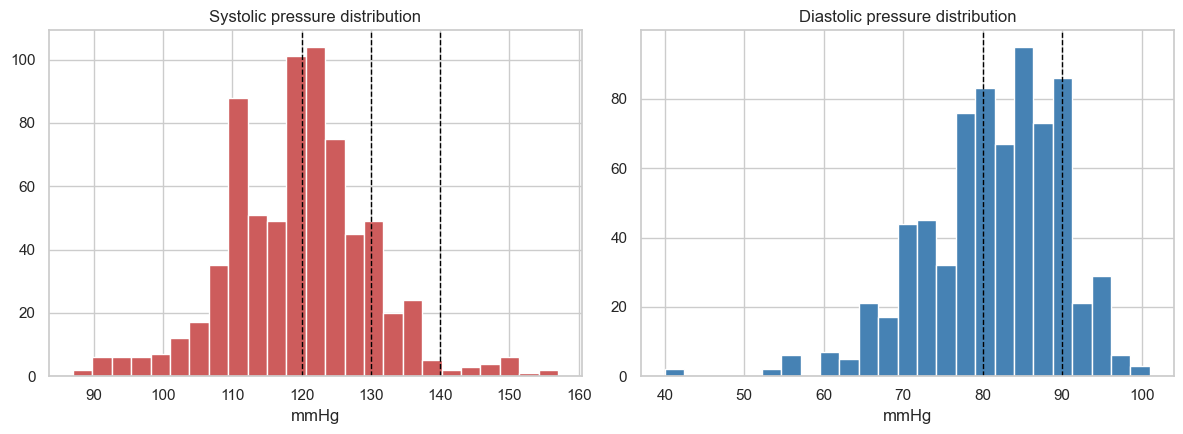

In [13]:
# Visualization 1: distributions of systolic and diastolic pressure, with AHA cutoffs marked
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(merged["systolic"], bins=25, color="indianred", edgecolor="white")
for cutoff, label in [(120, "Elevated"), (130, "Stage 1"), (140, "Stage 2")]:
    axes[0].axvline(cutoff, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Systolic pressure distribution")
axes[0].set_xlabel("mmHg")

axes[1].hist(merged["diastolic"], bins=25, color="steelblue", edgecolor="white")
for cutoff, label in [(80, "Stage 1"), (90, "Stage 2")]:
    axes[1].axvline(cutoff, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Diastolic pressure distribution")
axes[1].set_xlabel("mmHg")

plt.tight_layout()
plt.show()


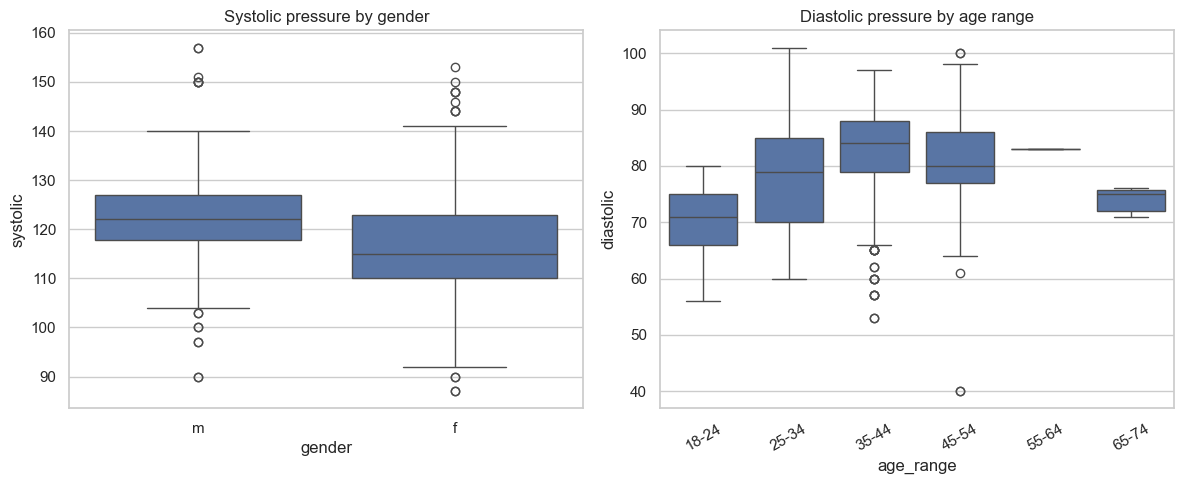

In [14]:
# Visualization 2: blood pressure distributions by gender and by age range
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=merged, x="gender", y="systolic", ax=axes[0])
axes[0].set_title("Systolic pressure by gender")

age_order = sorted(merged["age_range"].dropna().unique(), key=lambda x: int(x.split("-")[0]))
sns.boxplot(data=merged, x="age_range", y="diastolic", order=age_order, ax=axes[1])
axes[1].set_title("Diastolic pressure by age range")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


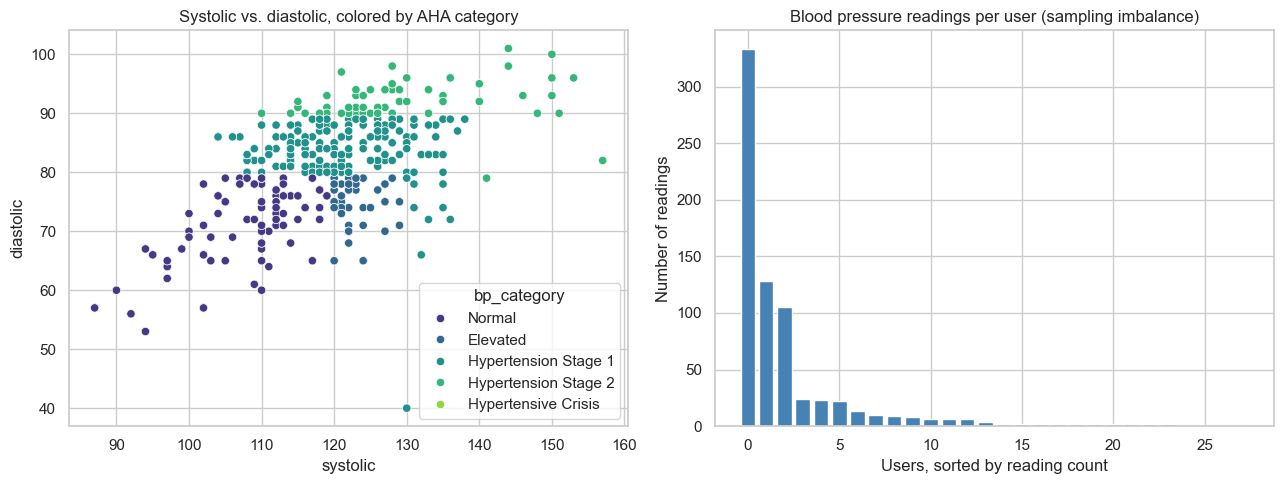

Top 3 users contribute 566 of 721 readings (78.5%)


In [15]:
# Visualization 3: systolic vs diastolic by BP category, and the per-user sampling imbalance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=merged, x="systolic", y="diastolic", hue="bp_category",
    hue_order=["Normal", "Elevated", "Hypertension Stage 1", "Hypertension Stage 2", "Hypertensive Crisis"],
    palette="viridis", ax=axes[0],
)
axes[0].set_title("Systolic vs. diastolic, colored by AHA category")

counts = blood_pressure_df["user_code"].value_counts()
axes[1].bar(range(len(counts)), counts.values, color="steelblue")
axes[1].set_title("Blood pressure readings per user (sampling imbalance)")
axes[1].set_xlabel("Users, sorted by reading count")
axes[1].set_ylabel("Number of readings")

plt.tight_layout()
plt.show()

print(f"Top 3 users contribute {counts.iloc[:3].sum()} of {counts.sum()} readings "
      f"({counts.iloc[:3].sum() / counts.sum():.1%})")


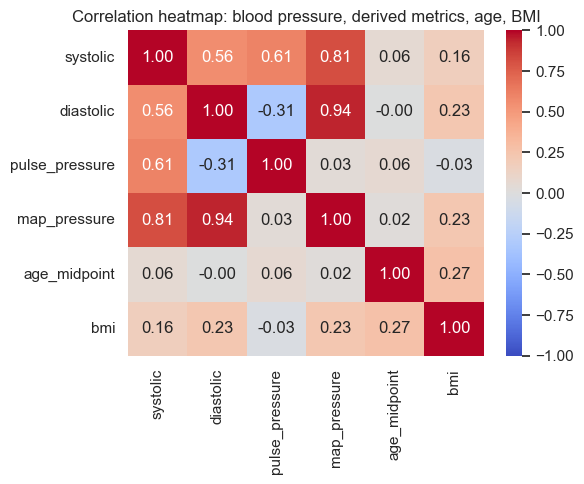

In [16]:
# Visualization 4: correlation heatmap of key numeric variables
numeric_cols = ["systolic", "diastolic", "pulse_pressure", "map_pressure", "age_midpoint", "bmi"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(merged[numeric_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation heatmap: blood pressure, derived metrics, age, BMI")
plt.tight_layout()
plt.show()


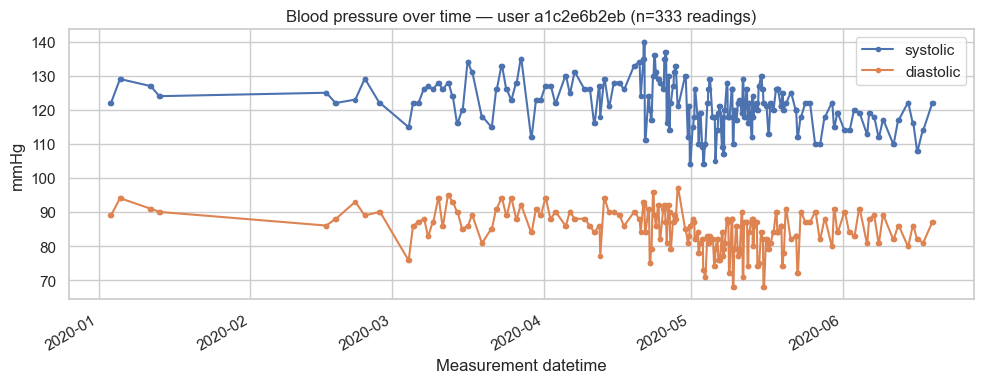

In [17]:
# Visualization 5: within-person blood pressure over time for the most heavily-sampled user
top_user = blood_pressure_df["user_code"].value_counts().idxmax()
top_bp = bp_clean[bp_clean["user_code"] == top_user].sort_values("measurement_datetime")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(top_bp["measurement_datetime"], top_bp["systolic"], marker="o", markersize=3, label="systolic")
ax.plot(top_bp["measurement_datetime"], top_bp["diastolic"], marker="o", markersize=3, label="diastolic")
ax.set_title(f"Blood pressure over time — user {top_user} (n={len(top_bp)} readings)")
ax.set_xlabel("Measurement datetime")
ax.set_ylabel("mmHg")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Interpretation of visualizations

- The histograms show a real cluster of readings in the Stage 1/2 hypertension range, not just a normal distribution centered on "Normal."
- The boxplots suggest diastolic creeps up with age, but the older age bins have very few people.
- The scatter plot confirms the AHA categories were assigned correctly and shows systolic/diastolic aren't perfectly correlated.
- The per-user bar chart is the clearest evidence of the sampling imbalance: 3 of 28 users account for most of the readings.
- The correlation heatmap backs up what's already in the correlation tables above.
- The time series for the most-sampled user shows blood pressure moving around week to week rather than trending one direction.


## Data Quality Assessment

**Profiling & completeness:** the core blood pressure columns (systolic, diastolic, user_code, datetime) are 100% complete, but the four derived indices are 58-61% missing. `participants.csv` is mostly complete except `symptoms_onset` (~20% missing). Completeness varies a lot by column, which is why I don't use one blanket rule for missing values.

**Accuracy:** two real issues came up. `sleep_duration` is actually in seconds, not hours like the documentation says. One blood pressure row has diastolic higher than systolic, and three participant heights are outside a plausible adult range (one is exactly 250cm), which look like data entry errors.

**Consistency:** datetime formats and categorical values (gender, age_range) are consistent across files. The one inconsistency is `sleep.csv` sometimes having two sleep sessions logged for the same day.

**Integrity:** every user in `blood_pressure.csv` also shows up in `participants.csv` and `heart_rate.csv`, so merges don't lose rows. There are no duplicate keys in `blood_pressure` or `participants`.

**Lineage & provenance:** this data comes from the Welltory HRV-19 open COVID-19 dataset ([GitHub](https://github.com/Welltory/hrv-covid19)), released in 2020 by Welltory (an HRV app company) so researchers could study COVID-19 recovery using wearable data. Users volunteered this data themselves after suspecting they had COVID-19, which explains a lot of the sampling imbalance and why the derived indices are missing so often (they need a matching heart rate reading).


## Conclusion: What are the implications of higher blood pressure?

Within this sample, higher blood pressure is most strongly tied to worse scores on Welltory's own derived cardiovascular indices since it looks like `functional_changes_index` correlates with systolic at about 0.68, well above BMI, age, or heart rate. `robinson_index` and `kerdo_vegetation_index` point the same direction. So the clearest story here is that higher blood pressure goes along with reduced cardiovascular adaptive capacity.

Beyond that, blood pressure has a weak positive relationship with BMI and age, and a small negative relationship with average heart rate. About half the readings fall into Stage 1/2 hypertension by the AHA categories, but that's mostly driven by 3 users who account for ~78% of all readings, so it says more about those individuals than about the group as a whole.

**Limitations:**
- Only 28 of 185 participants have blood pressure data at all, and they're not necessarily representative of the full group.
- 3 users dominate the readings, so the aggregate stats are really describing a few people.
- The derived-index correlations come from an even smaller subset (283 rows) that might not be a random slice of the full data.
- Blood pressure here is self-measured via an app during a pandemic, not clinical-grade.
